In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
latent_representations = xr.open_dataset('latent_representations_zmean.nc')

In [3]:
latent_representations

<xarray.Dataset> Size: 528kB
Dimensions:     (time: 6000, latent_dim: 20)
Coordinates:
  * time        (time) int64 48kB 0 1 2 3 4 5 ... 5994 5995 5996 5997 5998 5999
  * latent_dim  (latent_dim) int64 160B 0 1 2 3 4 5 6 7 ... 13 14 15 16 17 18 19
Data variables:
    z_mean      (time, latent_dim) float32 480kB ...
Attributes:
    model:        beta-VAE
    random_seed:  1
    description:  Latent-Space Representations (0.0005) from encoder (z_mean ...

In [4]:
# grab posterior means first
lr = latent_representations['z_mean']

In [5]:
lr.values

array([[-0.12258147,  0.25603944,  0.6312545 , ...,  0.0940879 ,
        -1.5572528 ,  0.2875531 ],
       [-0.801713  , -0.3978664 ,  0.1733985 , ..., -1.8291653 ,
        -1.2537111 ,  0.5276445 ],
       [-0.74800396,  0.28014246,  0.69813895, ..., -0.3380932 ,
        -1.3104343 , -0.04908151],
       ...,
       [-2.067489  , -1.4047574 , -0.45165253, ...,  0.8649288 ,
         1.074722  ,  0.6708392 ],
       [-1.9901968 , -0.93182087,  0.23356184, ...,  1.0040476 ,
         0.48372182,  1.2567449 ],
       [-1.2761182 , -0.5586201 ,  1.2064962 , ...,  0.0723231 ,
         0.3178261 ,  1.3992177 ]], dtype=float32)

In [6]:
lr_centered = lr.values - np.mean(lr.values, axis=0)

In [7]:
lr_centered

array([[ 0.1839563 ,  0.12732376,  0.81627995, ...,  0.76991755,
        -1.0071676 ,  0.27915084],
       [-0.4951752 , -0.52658206,  0.35842395, ..., -1.1533357 ,
        -0.703626  ,  0.5192423 ],
       [-0.44146618,  0.15142678,  0.8831644 , ...,  0.33773646,
        -0.7603492 , -0.05748376],
       ...,
       [-1.7609512 , -1.533473  , -0.26662707, ...,  1.5407584 ,
         1.6248071 ,  0.66243696],
       [-1.6836591 , -1.0605365 ,  0.41858727, ...,  1.6798773 ,
         1.0338069 ,  1.2483426 ],
       [-0.9695804 , -0.6873358 ,  1.3915217 , ...,  0.74815273,
         0.8679112 ,  1.3908155 ]], dtype=float32)

In [8]:
var_per_dim = np.var(lr_centered, axis=0)

In [9]:
var_per_dim

array([0.8935747 , 0.5537981 , 0.47287118, 0.44424608, 0.30758998,
       0.5164839 , 0.4195845 , 0.55718774, 0.5809101 , 0.562739  ,
       0.4374395 , 0.64761466, 0.3457667 , 0.434889  , 0.48110792,
       0.37913114, 0.64810085, 0.5300453 , 0.37434945, 0.5132241 ],
      dtype=float32)

In [10]:
total_variance = np.sum(var_per_dim)

In [11]:
total_variance

10.100655

In [12]:
explained_variance_ratio = var_per_dim / total_variance

In [13]:
explained_variance_ratio.shape

(20,)

In [14]:
explained_variance_ratio * 100

array([8.846701 , 5.482794 , 4.6815896, 4.398191 , 3.0452478, 5.113371 ,
       4.1540327, 5.5163527, 5.751212 , 5.5713124, 4.3308034, 6.4116106,
       3.4232106, 4.3055525, 4.763136 , 3.7535303, 6.4164243, 5.247633 ,
       3.70619  , 5.0810976], dtype=float32)

In [15]:
explained_variance_ratio.sum()

0.99999994

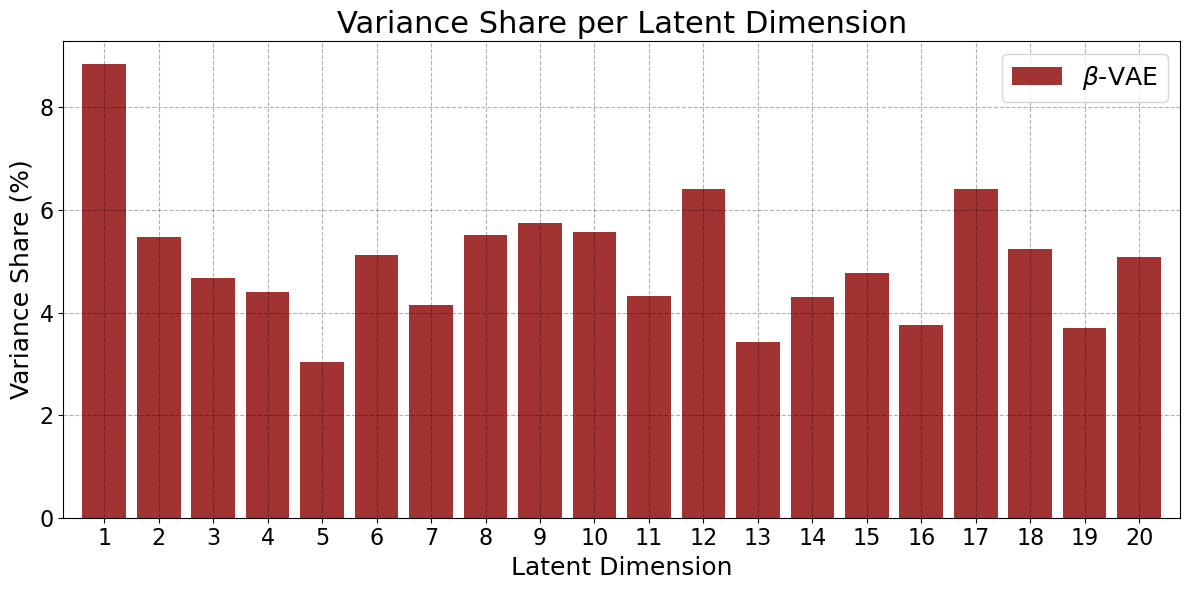

In [16]:
dims = np.arange(1,21)

plt.figure(figsize=(12,6))
plt.grid(True, alpha=0.3, linestyle='--', color='black')
plt.bar(dims,
        explained_variance_ratio * 100,
        label=r'$\beta$-VAE',
        alpha=0.8,
        color='darkred')

plt.xlim(dims[0] - 0.75, dims[-1] + 0.75)
plt.xlabel('Latent Dimension', fontsize=18)
plt.xticks(dims, fontsize=16)
plt.ylabel('Variance Share (%)', fontsize=18)
plt.yticks(fontsize=16)
plt.title('Variance Share per Latent Dimension', fontsize=22)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig('bvae_variance_0309.pdf', bbox_inches='tight')
plt.show()